Текущая рабочая директория: /Users/fluloeo/Documents/drift_aware/project
Calculating SHAP for 10 models on 2068 samples...


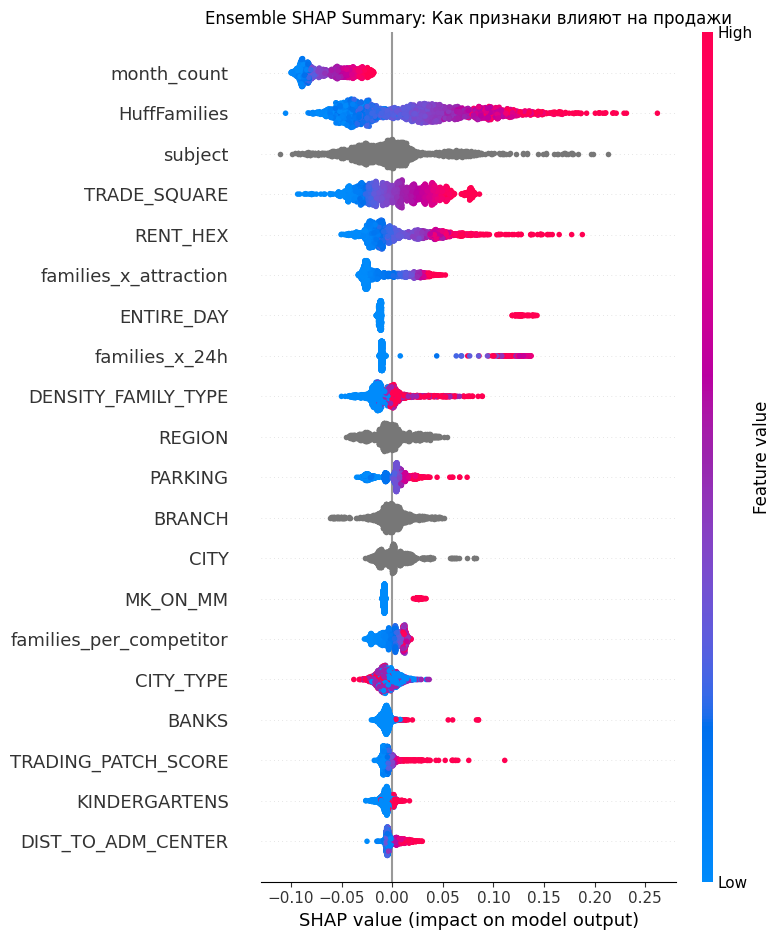

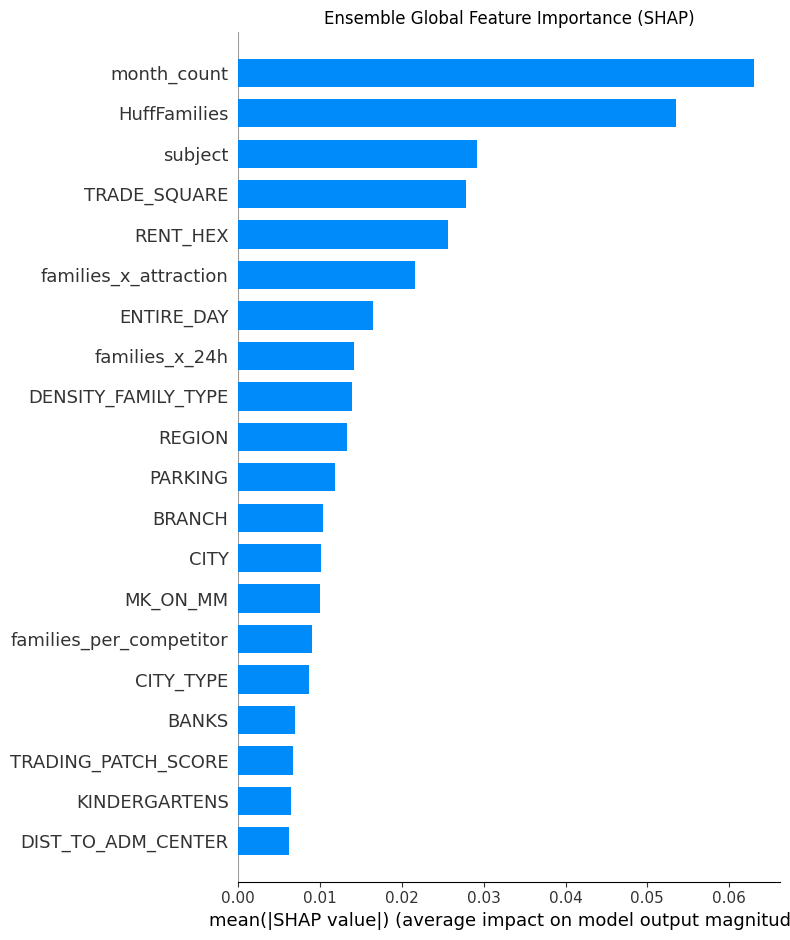

/var/folders/5w/td1qssr102g_shnry7z0q4k00000gn/T/ipykernel_7926/76981931.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weights_df, x='weight', y='feature', palette='magma')


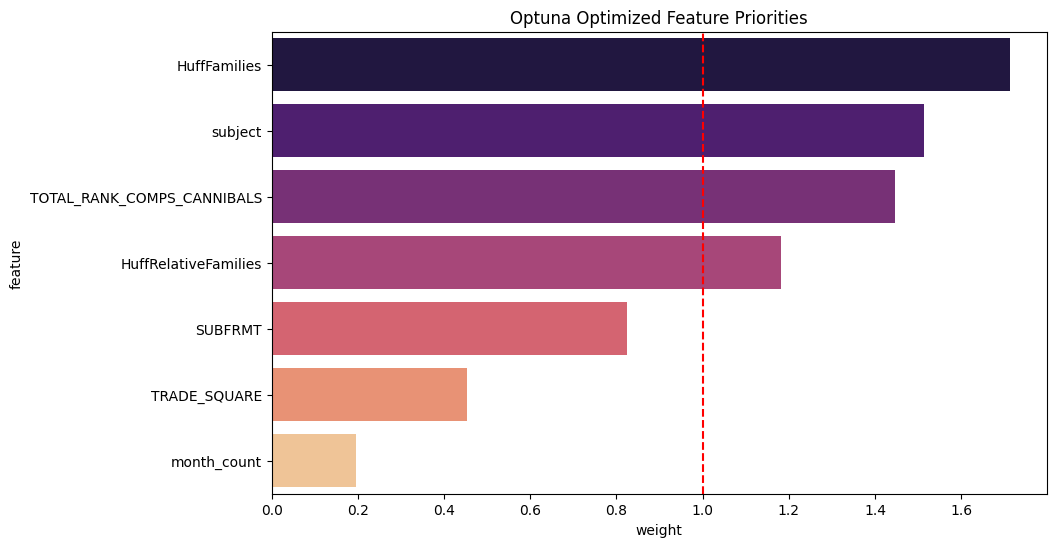

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

import glob
import json
from catboost import CatBoostRegressor
import sys
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.append(os.getcwd())

MODELS_DIR = 'models'
DATA_VAL_PATH = 'data/train/val.csv'
METADATA_PATH = os.path.join(MODELS_DIR, 'metadata.json')

if not os.path.exists(METADATA_PATH):
    raise FileNotFoundError(f"Не найден файл метаданных: {METADATA_PATH}")

with open(METADATA_PATH, 'r') as f:
    meta = json.load(f)

features = meta['features']

val = pd.read_csv(DATA_VAL_PATH)

df_interpret = add_features_inference(val) 
X_interpret = df_interpret[features]

model_files = glob.glob(os.path.join(MODELS_DIR, '*.cbm'))
if not model_files:
    raise FileNotFoundError(f"В папке {MODELS_DIR} не найдено ни одного .cbm файла")

all_shap_values = []

print(f"Calculating SHAP for {len(model_files)} models on {len(X_interpret)} samples...")

for model_path in model_files:
    model = CatBoostRegressor()
    model.load_model(model_path)
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_interpret)
    all_shap_values.append(shap_values)

mean_ensemble_shap = np.mean(all_shap_values, axis=0)
shap.initjs()

plt.figure(figsize=(12, 8))
plt.title("Ensemble SHAP Summary: Как признаки влияют на продажи")
shap.summary_plot(mean_ensemble_shap, X_interpret, show=False)
plt.show()

plt.figure(figsize=(12, 8))
plt.title("Ensemble Global Feature Importance (SHAP)")
shap.summary_plot(mean_ensemble_shap, X_interpret, plot_type="bar", show=False)
plt.show()

if 'best_params_found' in meta:
    import seaborn as sns

    best_params = meta['best_params_found']
    weight_keys = [k for k in best_params.keys() if k.startswith('w_')]
    
    mapping = {
        'w_trcc': 'TOTAL_RANK_COMPS_CANNIBALS',
        'w_sub': 'SUBFRMT',
        'w_mc': 'month_count',
        'w_hf': 'HuffFamilies',
        'w_ts': 'TRADE_SQUARE',
        'w_subj': 'subject',
        'w_hrf': 'HuffRelativeFamilies'
    }
    
    weights_data = []
    for k in weight_keys:
        feat_name = mapping.get(k, k)
        weights_data.append({'feature': feat_name, 'weight': best_params[k]})
    
    weights_df = pd.DataFrame(weights_data).sort_values(by='weight', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=weights_df, x='weight', y='feature', palette='magma')
    plt.axvline(x=1.0, color='red', linestyle='--')
    plt.title("Optuna Optimized Feature Priorities")
    plt.show()